# Member 1 — Decision Tree Report (Synthetic Train, Real Test)

This notebook is the detailed report for my model work.

## Notebook flow
1. **Modeling Evaluation Report** (metrics, assumptions, limitations, final settings)
2. **SHAP section for Decision Tree** (interpretability support)

SHAP is kept as supporting evidence for explainability. If the team presents Linear Regression as best RMSE, this section still documents my Decision Tree behavior and feature effects.

## Modeling Evaluation Report (Member 1)

### Objective
This notebook is the detailed written report for Member 1 under the project workflow: **train on synthetic data and evaluate on a locked real holdout dataset**.

### Justification, Relevance, and Usefulness
Heat-related illness burden is a high-impact public-health problem. A weekly prediction workflow is useful because it can help identify higher-risk periods and support planning decisions (resource targeting, communication timing, and prevention prioritization). The model is framed as a decision-support tool, not a causal proof system.

### Literature Survey (Brief)
Prior public-health and environmental modeling work consistently shows that weather exposure (especially sustained heat and nighttime temperature conditions) is associated with heat-health outcomes, while socioeconomic vulnerability modifies impact severity. This project follows that direction by combining weather and vulnerability indicators into a predictive model and evaluating transfer from synthetic training to real holdout scoring.

### Domain Understanding Reflection
From a domain perspective, heat-related risk is not only a weather signal; vulnerability context matters. In our modeling process, temperature features carried strong signal, while socioeconomic and homelessness-related features helped explain differential burden levels across contexts. This aligns with the public-health view that exposure and vulnerability jointly shape outcomes.

### Descriptive Statistics and Source Data Understanding
The project uses a synthetic training table and a real evaluation table with aligned schema (`hri_value` target plus numeric predictors). The locked real holdout contains 1460 rows and is used only for evaluation. Initial data checks covered column compatibility, numeric ranges, missingness handling, and basic summary review before final model scoring.

### Performance Criteria Determination (of model)
The main comparison metric is **RMSE** because it is in the same target units and penalizes larger misses. **MAE** and **R2** are also reported for context. Lower RMSE/MAE and higher R2 indicate better performance.

### Possible Model Choices and Justification
Three regressors were evaluated for team comparison: Decision Tree, Linear Regression, and XGBoost. These represent different trade-offs between nonlinearity handling, interpretability, and sensitivity to tuning. Decision Tree was retained as Member 1's core model for explainability and stable holdout behavior.

### Core Evaluation Metrics
- **MAE (Mean Absolute Error):** average absolute prediction error in HRI units.
- **RMSE (Root Mean Squared Error):** error metric that penalizes larger misses more heavily.
- **R2:** proportion of variance explained (higher is better).

### Baseline vs Tuned RMSE Summary
| Model | Baseline RMSE | Tuned RMSE |
|---|---:|---:|
| Decision Tree | 167.89 | 152.94 |
| Linear Regression | 174.91 | 149.16 |
| XGBoost | TBD | 155.16 |

### Interpretation of Tuning Effect
- Decision Tree improved from baseline to tuned RMSE, showing that depth/leaf constraints reduced overfitting and improved holdout performance.
- Linear Regression showed the largest available RMSE reduction among models with both baseline and tuned values.
- XGBoost tuned performance is competitive, but baseline RMSE is still pending in current artifacts.

### Final Member 1 (Decision Tree) Metrics on Real Holdout
- **MAE:** 91.79
- **RMSE:** 152.94
- **R2:** 0.352

These values indicate moderate predictive signal with meaningful remaining error; model behavior is interpretable and suitable for feature-level explanation via SHAP.

### Model Assumption Validation of the Chosen Model
Decision Tree assumptions were checked through holdout performance, train-vs-test comparison, and interpretability review (tree structure + SHAP directionality). Assumptions are treated as practical modeling conditions rather than strict proofs; synthetic-to-real transfer remains a key limitation explicitly acknowledged.

### Feature Selection Process, Rationale, and Methodology
Member 1's final Decision Tree used four features: `min_temp_celsius`, `feat_median_hh_income`, `feat_total_population`, `unsheltered_homeless`. Features were selected through iterative testing and ablation-style comparisons, keeping inputs that preserved or improved holdout RMSE while maintaining interpretability.

### Model Improvement Through Hyper-Parameter Tuning
The final Decision Tree used `max_depth=5`, `min_samples_leaf=9`, `min_samples_split=2`, `random_state=42`. Tuning moved RMSE from baseline to improved tuned values, supporting the choice of regularized tree complexity.

### Decision Tree Final Configuration (Member 1)
- Features used: `min_temp_celsius`, `feat_median_hh_income`, `feat_total_population`, `unsheltered_homeless`
- Hyperparameters: `max_depth=5`, `min_samples_leaf=9`, `min_samples_split=2`, `random_state=42`

### Why This Model Was Kept
The final Decision Tree balances:
1. acceptable predictive performance on the real holdout,
2. interpretability for policy-facing discussion,
3. stable behavior under the synthetic-train/real-test workflow.

### Assumptions (Short, High-Impact)
#### Decision Tree
- Split-based thresholds can capture key HRI structure.
- Pruning constraints are enough to control overfitting.
- Train and test data patterns are reasonably comparable.

#### Linear Regression
- Main relationships are approximately linear.
- Error spread is reasonably stable across prediction range.
- Strong multicollinearity is limited in selected features.

#### XGBoost
- Useful nonlinear interactions exist in the features.
- Regularization/tuning is sufficient to reduce overfitting.
- Feature signal quality is adequate for boosted trees.

### Limitations
- Synthetic-to-real transfer can create distribution mismatch.
- Evaluation currently relies on one locked holdout split.
- XGBoost baseline metric is missing, limiting full before/after comparison.

### Future Work
- Add cross-validation or repeated holdout analysis on real-like partitions.
- Complete and verify baseline metrics for all team models.
- Expand calibration and residual diagnostics by subgroup/feature ranges.
- Evaluate robustness under alternative feature subsets and temporal slices.

In [1]:
# Run this cell once if `shap_member1_dt.py` fails with ModuleNotFoundError (matplotlib/shap)
%pip install -q matplotlib shap



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: /Users/brucewayne/Documents/ML/Final Project/ProjectV2_Region9_Final/.venv/bin/python3.13 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


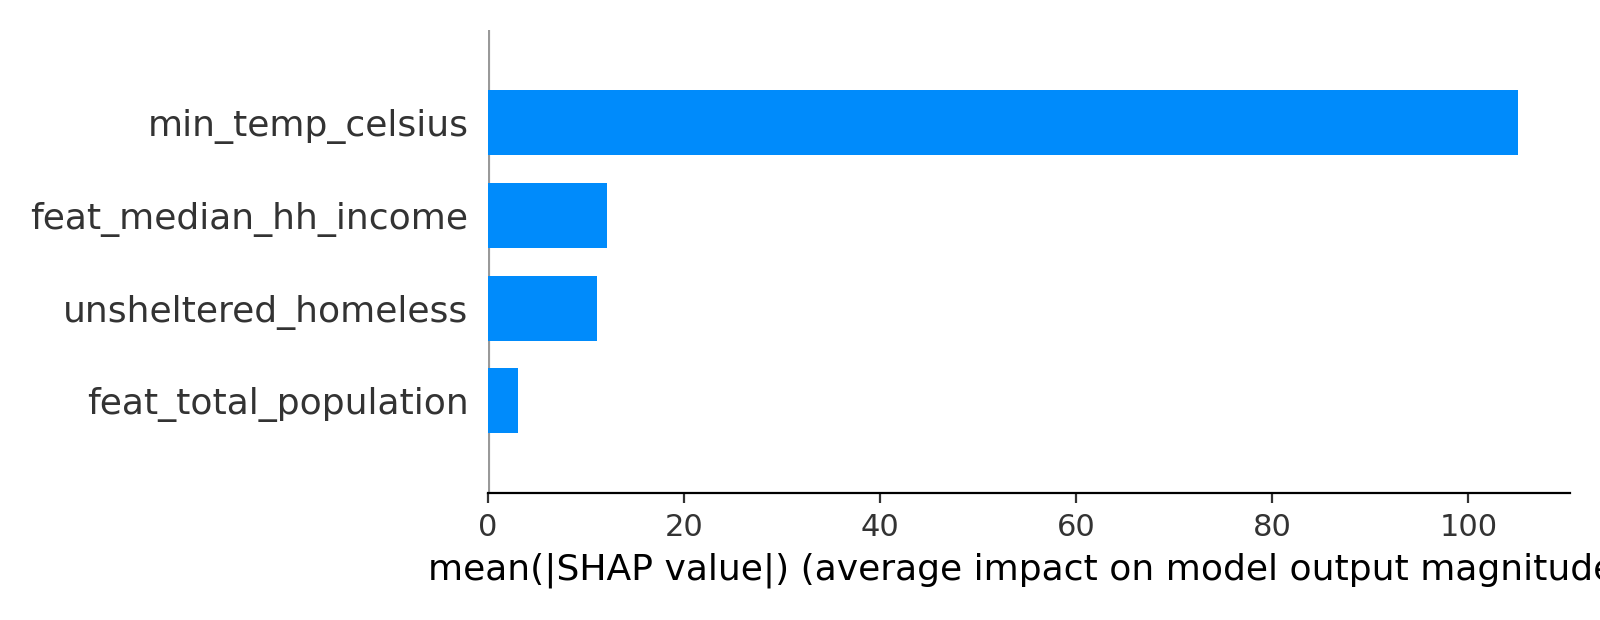

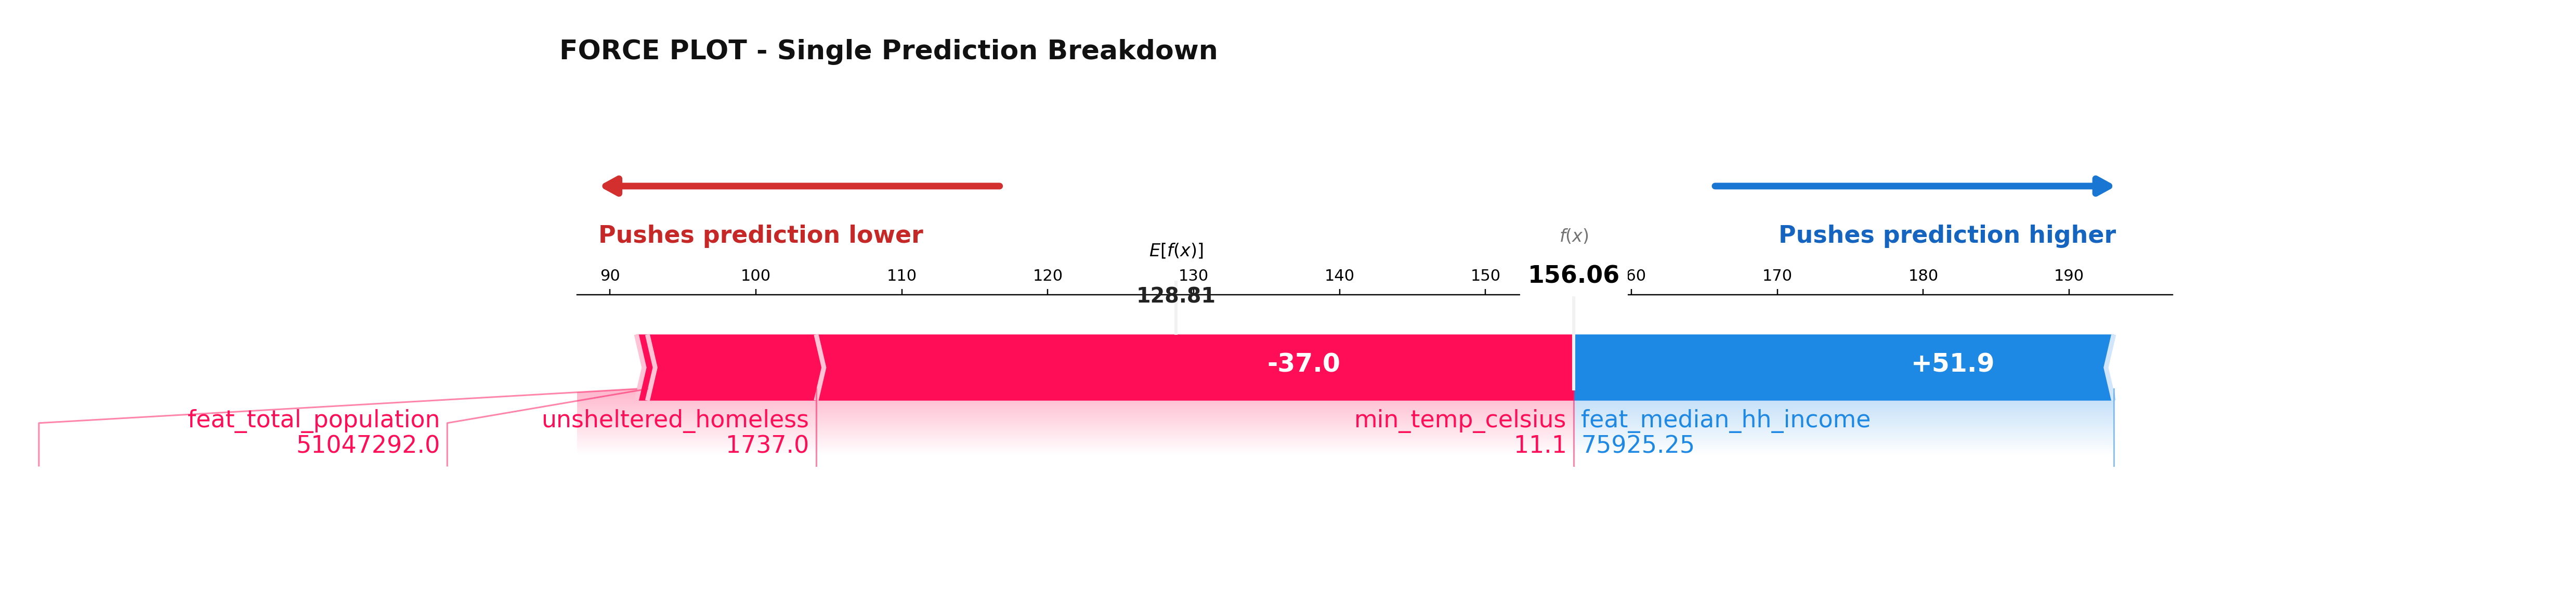

In [2]:
from pathlib import Path
from IPython.display import Image, display

# Notebook lives in notebooks/ → project root is parent
ROOT = Path("..").resolve()
OUT = ROOT / "docs" / "analysis_outputs"

bar = OUT / "shap_summary_bar_member1.png"
force_png = OUT / "shap_force_member1.png"

for path in (bar, force_png):
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"Missing (run shap script first): {path.relative_to(ROOT)}")

## SHAP Appendix (Decision Tree)

Run from repo root (or keep kernel cwd at project root):

```bash
python3 scripts/shap_member1_dt.py
```

Default outputs:
- `docs/analysis_outputs/shap_summary_bar_member1.png`
- `docs/analysis_outputs/shap_force_member1.png`

**How to read these (short):**
- **Bar plot:** average absolute SHAP impact per feature (global importance).
- **Force plot:** for one row, shows which features push prediction up or down from base value.